# Imports

In [1]:
#import packages
import numpy as np
import json 
import scanpy as sc
from collections import OrderedDict
import scipy 
import pandas as pd
import matplotlib.pyplot as plt
import pickle

#spectra imports 
import Spectra 
from Spectra import Spectra_util as spc_tl
from Spectra import K_est as kst
from Spectra import default_gene_sets

/Users/mkaur/miniconda3/envs/spectra/lib/python3.10/site-packages/Spectra/Spectra_util.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
pwd

'/Users/mkaur/github/2_tff1/1_tecs/1_pyzone/0_notebooks/0_scRNA/5_spectra'

In [3]:
adata = sc.read_h5ad('/Users/mkaur/github/2_tff1/1_tecs/1_pyzone/3_h5ad/8_adata_final.h5ad')
adata

AnnData object with n_obs × n_vars = 10336 × 33594
    obs: 'sample', 'log10_original_total_counts', 'n_genes_by_counts', 'ribo_frac', 'mito_frac', 'cell_type', 'cell_type_subset'
    uns: 'cell_type_colors', 'cell_type_subset_colors', 'log1p', 'neighbors', 'pca', 'sample_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'raw_data'
    obsp: 'connectivities', 'distances'

In [5]:
adata.obs['cell_type_subset'].value_counts()

cell_type_subset
0:cTEC                        2413
11:mimetic(tuft)              1838
3:mTEC2                       1231
5:mimetic(corneocyte-like)    1209
4:mimetic(goblet)              783
1:mTEC1                        498
7:mimetic(neuroendo)           406
14:vEC                         391
13:capEC                       371
19:MEC                         246
6:mimetic(microfold)           222
2:mTEC-prol                    168
18:vSMC/PC                     113
16:capsFB/intFB                112
12:aEC                         110
9:mimetic(ciliated)             73
15:fetalEC                      57
8:mimetic(ionocyte)             52
17:medFB                        22
10:mimetic(parathyroid)         21
Name: count, dtype: int64

In [8]:
adata.obs['cell_type_clean'] = (
    adata.obs['cell_type_subset']
    .str.replace(r'^\d+:', '', regex=True)
)

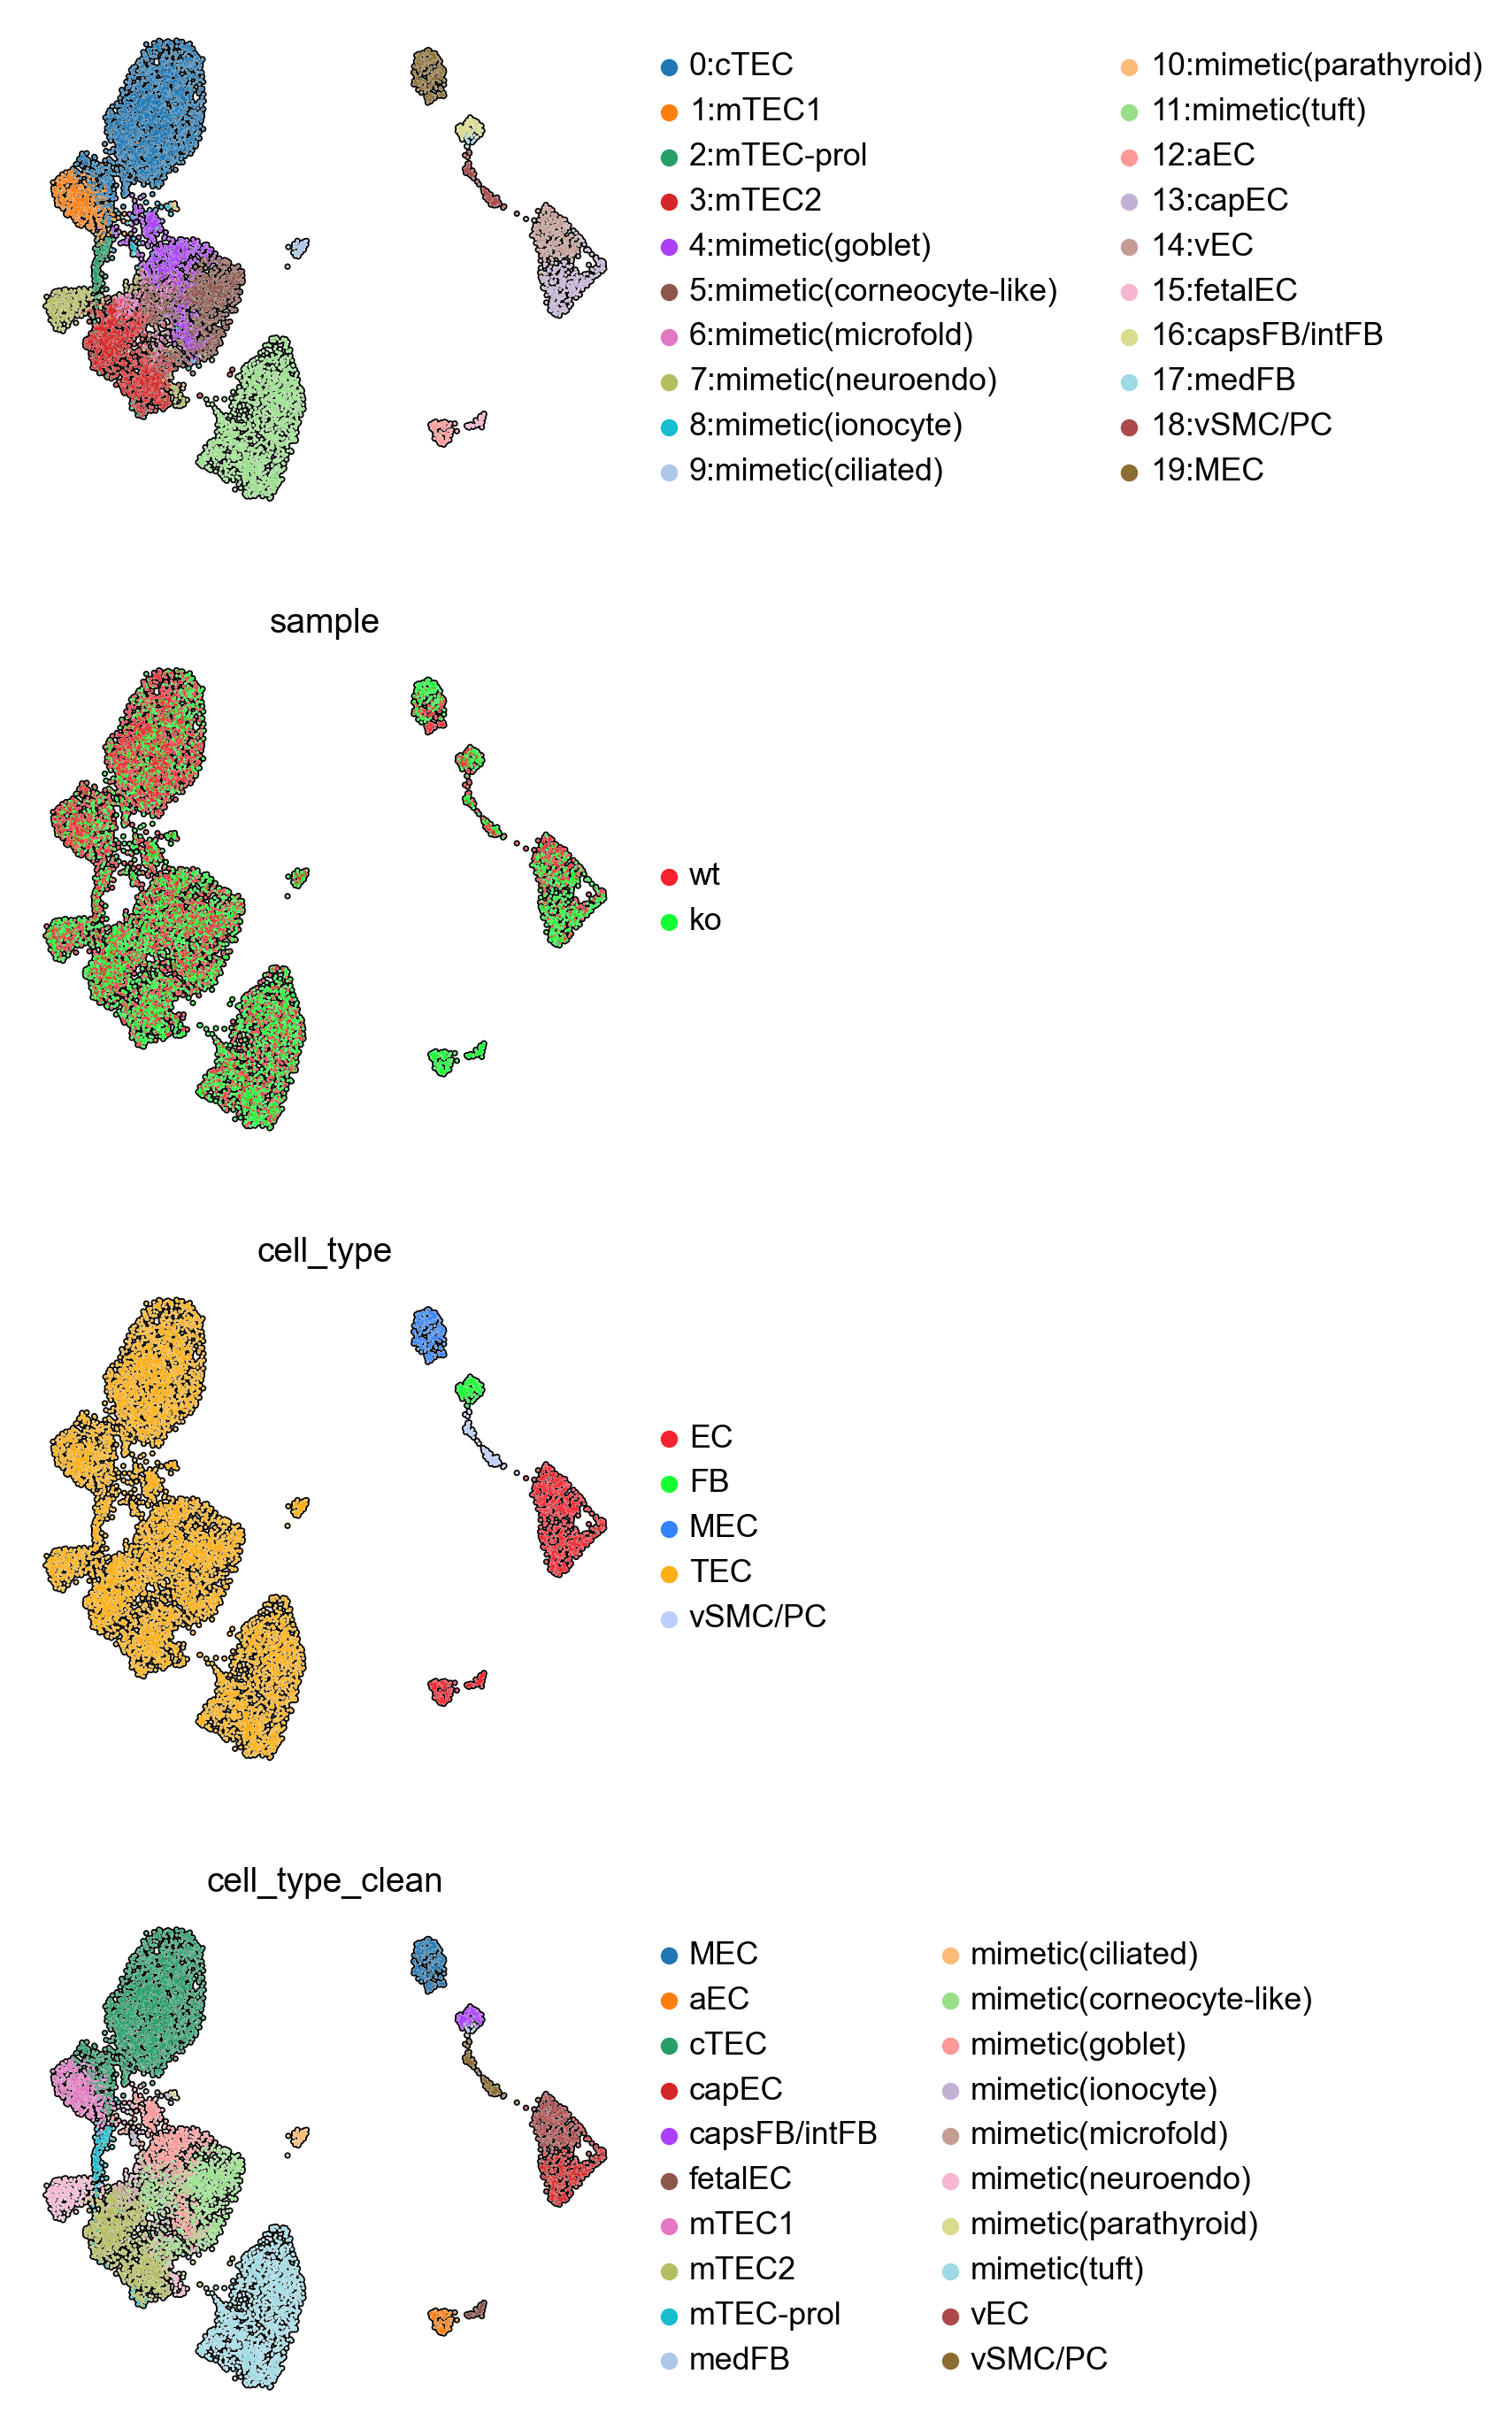

In [9]:
sc.set_figure_params(dpi=100, dpi_save=300, color_map='Spectral_r', vector_friendly=True, transparent=True)
sc.pl.umap(
    adata, 
    color=['cell_type_subset', 'sample', 'cell_type', 'cell_type_clean'],  
    ncols=1,
    size =5, 
    outline_width=[0.6, 0.05],
    frameon=False,
    cmap='Spectral_r',
    use_raw=False, 
    #vmax = 'p99', 
    add_outline=True,
    #legend_loc = 'on data', 
    title='',
    #save='_annotation.pdf'
)

# Set up Spectra Dict

In [11]:
adata.obs['distinct'] = adata.obs['sample'].astype(str) + '_' + adata.obs['cell_type_clean'].astype(str)
adata.obs['distinct'].value_counts()

distinct
wt_cTEC                        1547
ko_mimetic(tuft)               1181
ko_cTEC                         866
ko_mTEC2                        746
wt_mimetic(tuft)                657
ko_mimetic(corneocyte-like)     650
wt_mimetic(corneocyte-like)     559
wt_mTEC2                        485
ko_mimetic(goblet)              419
wt_mimetic(goblet)              364
wt_mTEC1                        321
ko_capEC                        278
ko_mimetic(neuroendo)           230
ko_vEC                          198
wt_vEC                          193
ko_mTEC1                        177
wt_mimetic(neuroendo)           176
ko_MEC                          152
ko_mimetic(microfold)           140
ko_aEC                          110
wt_MEC                           94
wt_capEC                         93
ko_mTEC-prol                     86
wt_mTEC-prol                     82
wt_mimetic(microfold)            82
ko_capsFB/intFB                  69
ko_vSMC/PC                       60
ko_fetalEC         

In [12]:
sc.tl.rank_genes_groups(adata, groupby='distinct', method='wilcoxon', use_raw=False)
result = adata.uns['rank_genes_groups']
groups = result['names'].dtype.names
df = pd.DataFrame(
    {group + '_' + key[:1]: result[key][group]
    for group in groups for key in ['names']}).head(100) #'scores', 'logfoldchanges', 'pvals_adj'

df.head()

/Users/mkaur/miniconda3/envs/spectra/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/Users/mkaur/miniconda3/envs/spectra/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:460: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/Users/mkaur/miniconda3/envs/spectra/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:463: P

,ko_MEC_n,ko_aEC_n,ko_cTEC_n,ko_capEC_n,ko_capsFB/intFB_n,ko_fetalEC_n,ko_mTEC1_n,ko_mTEC2_n,ko_mTEC-prol_n,ko_medFB_n,...,wt_mimetic(ciliated)_n,wt_mimetic(corneocyte-like)_n,wt_mimetic(goblet)_n,wt_mimetic(ionocyte)_n,wt_mimetic(microfold)_n,wt_mimetic(neuroendo)_n,wt_mimetic(parathyroid)_n,wt_mimetic(tuft)_n,wt_vEC_n,wt_vSMC/PC_n
0,Upk3b,Tspan7,Shisa2,Fabp4,Col6a3,Prickle2,Ccl21a,Syt1,Aire,Lrp1,...,Spata18,Skint3,Anxa1,Cab39,Muc13,Rap1gap2,Kansl1l,Ivns1abp,Pecam1,Prkg1
1,Aldh1a2,Calcrl,Pax1,Cd36,Postn,Emp2,Lifr,Ubd,S100a2,Col1a2,...,Ccdc153,Spink5,Gabrp,Clint1,Bcl2l15,Stxbp5l,Npnt,Mctp1,Cd93,Zeb2
2,Aebp1,Nckap5,Ctsl,Sptbn1,Lhfp,Aff3,Robo1,Fcgbp,S100a3,Mmp2,...,Sntn,Dapl1,Serpinb11,Akap13,Cldn7,Ptprn2,Pcyt1b,Avil,Ldb2,Dlc1
3,Efemp1,Epas1,Pltp,Fli1,Ank2,Pmp22,Kcnma1,Cd74,Icosl,Pdgfra,...,1700016K19Rik,Ly6d,Gsto1,Bdp1,Apobec1,Fchsd2,Sycp2l,Bmx,Emcn,Nr2f2
4,Igfbp6,Bmpr2,Mtss2,Cav1,Enpp2,Prx,Eya4,Myo3b,Il4i1,Lama2,...,Cfap206,Fam3d,Mlph,Ppargc1a,Hnf4g,Nol4,Myh10,Atp2a3,Apbb2,Gucy1b1


In [13]:
N = 35  # how many markers per cell type

gene_set_dictionary = {}
for ct in groups:
    # Grab the top N names, ensure strings, drop NaNs/empties, keep unique order
    names = pd.Series(result['names'][ct]).astype(str)
    names = names.replace({'nan': np.nan}).dropna()
    # Keep order-unique
    seen = set()
    topN = [g for g in names.tolist() if (g not in seen and not seen.add(g))][:N]
    
    # One gene set per cell type
    gene_set_dictionary[ct] = {f'{ct}': topN}

In [14]:
gene_set_dictionary

{'ko_MEC': {'ko_MEC': ['Upk3b',
   'Aldh1a2',
   'Aebp1',
   'Efemp1',
   'Igfbp6',
   'Ptgis',
   'Lrrn4',
   'Nkain4',
   'Rspo1',
   'Csrp2',
   'Upk1b',
   'Gpm6a',
   'Ildr2',
   'Pals2',
   'Rarres2',
   'Wt1',
   'Dcn',
   'Timp2',
   'Fbln1',
   'Igfbp4',
   'Cldn15',
   'Serping1',
   'Lgals1',
   'C3',
   'Mgp',
   'Fndc1',
   'Sox6',
   'Flrt2',
   'C4b',
   'Muc16',
   'Dpp4',
   'Gm12840',
   'Cdon',
   'Col1a2',
   'Plac9']},
 'ko_aEC': {'ko_aEC': ['Tspan7',
   'Calcrl',
   'Nckap5',
   'Epas1',
   'Bmpr2',
   'Acvrl1',
   'Ramp2',
   'Ace',
   'Tmem100',
   'Adgrf5',
   'Ehd4',
   'Ptprb',
   'Adgre5',
   'Clec14a',
   'Tek',
   'Pde3a',
   'Lyve1',
   'Cyp4b1',
   'Ldb2',
   'Adgrl3',
   'BC028528',
   'Foxf1',
   'Cyth3',
   'Ptprm',
   'Tspan13',
   'Ctla2a',
   'Cav1',
   'Fendrr',
   'Cd93',
   'Eng',
   'Egfl7',
   'Afap1l1',
   'Clec1a',
   'Phldb2',
   'Heg1']},
 'ko_cTEC': {'ko_cTEC': ['Shisa2',
   'Pax1',
   'Ctsl',
   'Pltp',
   'Mtss2',
   'Gas6',
   'Tenm4',

In [15]:
sc.tl.rank_genes_groups(adata, groupby='cell_type', method='wilcoxon', use_raw=False)
result = adata.uns['rank_genes_groups']
groups = result['names'].dtype.names
df = pd.DataFrame(
    {group + '_' + key[:1]: result[key][group]
    for group in groups for key in ['names']}).head(100) #'scores', 'logfoldchanges', 'pvals_adj'

df.head()

,EC_n,FB_n,MEC_n,TEC_n,vSMC/PC_n
0,Ptprm,Col6a3,Aebp1,Epcam,Prkg1
1,Sptbn1,Lama2,Csrp2,Dsp,Zeb2
2,Pecam1,Col5a2,Igfbp6,Cdh1,Dlc1
3,Cd36,Ank2,Upk3b,Rbm47,Gucy1b1
4,Egfl7,Lhfp,Dcn,Spint2,Nr2f2


In [ ]:
#df['vSMC/PC_n'].head(35).to_list()

In [16]:
gene_set_dictionary['global'] = {
    'epithelial': ['Epcam',
 'Dsp',
 'Cdh1',
 'Rbm47',
 'Spint2',
 'Alcam',
 'Krt8',
 'Krt18',
 'H2-Eb1',
 'Ank3',
 'Gm15987',
 'Esrp1',
 'Spint1',
 'Patj',
 'Slc9a9',
 'H2-Ab1',
 'Map7',
 'Cd74',
 'Dsg2',
 'Cdcp1',
 'Sgpl1',
 'Tiam1',
 'H2-Aa',
 'Sorl1',
 'Eya4',
 'Pstpip2',
 'Parm1',
 'Ctnnd2',
 'Eya2',
 'Pclo',
 'Sfn',
 'Wwc1',
 'Mreg',
 'Snx29',
 'Tmem131l'],
    'fibroblast': ['Col6a3',
 'Lama2',
 'Col5a2',
 'Ank2',
 'Lhfp',
 'Col6a2',
 'Fbn1',
 'Col3a1',
 'Lum',
 'Col6a1',
 'Col1a2',
 'Ddr2',
 'Abi3bp',
 'Col1a1',
 'Bicc1',
 'Prrx1',
 'Zeb2',
 'Dlc1',
 'Bgn',
 'Dcn',
 'Apod',
 'Colec12',
 'Gsn',
 'Col5a1',
 'Col5a3',
 'Cd302',
 'Gpm6b',
 'Htra3',
 'Il1r1',
 'Pdgfra',
 'Mxra8',
 'Serpine2',
 'Enpp2',
 'Serping1',
 'Cygb'], 
    'endothelial': ['Ptprm',
 'Sptbn1',
 'Pecam1',
 'Cd36',
 'Egfl7',
 'Cdh5',
 'Adgrf5',
 'Flt1',
 'Arhgap31',
 'Adgrl4',
 'Eng',
 'Cav1',
 'Fli1',
 'Ptprb',
 'Nrp1',
 'Ly6c1',
 'Col4a1',
 'Prkch',
 'Shank3',
 'Kdr',
 'Prex2',
 'Epas1',
 'Apbb2',
 'Cavin2',
 'Esam',
 'Cyyr1',
 'Itga1',
 'S1pr1',
 'Col4a2',
 'Tcf4',
 'Emcn',
 'Ushbp1',
 'Ldb2',
 'Arhgap29',
 'Gng11'], 
    'mesothelial': ['Aebp1',
 'Csrp2',
 'Igfbp6',
 'Upk3b',
 'Dcn',
 'Rarres2',
 'C3',
 'Serping1',
 'Gpm6a',
 'Timp2',
 'Mgp',
 'Igfbp4',
 'C4b',
 'Aldh1a2',
 'Ptgis',
 'Abi1',
 'Lgals1',
 'C2',
 'Nkain4',
 'Efemp1',
 'Fbln1',
 'Pals2',
 'Wt1',
 'Rspo1',
 'Sox6',
 'Rnase4',
 'Cldn15',
 'Col1a2',
 'Upk1b',
 'Gata6',
 'Gm56730',
 'Fndc1',
 'Lrrn4',
 'Laptm4a',
 'Ccdc80'],
    'vSMC/PC':['Prkg1',
 'Zeb2',
 'Dlc1',
 'Gucy1b1',
 'Nr2f2',
 'Ednra',
 'Pde3a',
 'Plac9',
 'Sox5',
 'Sparcl1',
 'Gucy1a1',
 'Cacna1c',
 'Gjc1',
 'Pdgfrb',
 'Ndufa4l2',
 'Ebf1',
 'Lhfp',
 'Bgn',
 'Rhoj',
 'Prrx1',
 'Pde1a',
 'Mylk',
 'Gm13889',
 'Plcl1',
 'Serping1',
 'Notch3',
 'Arhgap10',
 'Ppp1r12a',
 'Rgs5',
 'Rarres2',
 'Cald1',
 'Myl9',
 'Sparc',
 'Pla2r1',
 'Lin7a']
                        }

In [18]:
#filter gene set annotation dict for genes contained in adata
annotations = Spectra.Spectra_util.check_gene_set_dictionary(adata,
                                                             gene_set_dictionary,
                                                             obs_key='distinct',
                                                             global_key='global')

Cell type labels in gene set annotation dictionary and AnnData object are identical
Your gene set annotation dictionary is now correctly formatted.


In [19]:
#adata.X = adata.X.toarray()

In [21]:
model = Spectra.est_spectra(adata=adata, 
                            gene_set_dictionary=gene_set_dictionary, 
                            use_highly_variable=False,
                            cell_type_key="distinct", 
                            use_weights=True,
                            lam=0.1, 
                            rho=0.001, 
                            use_cell_types=True,
                            n_top_vals=35,
                            label_factors=True, 
                            overlap_threshold=0.2,
                            clean_gs = True, 
                            min_gs_num = 3,
                            num_epochs=100 # For a more serious analysis, please make this 10000
                            )

Cell type labels in gene set annotation dictionary and AnnData object are identical
Your gene set annotation dictionary is now correctly formatted.


: 

In [ ]:
model.return_eta_diag()

In [ ]:
import pickle
with open('/coh_labs/mvandenbrink/users/pkaur/6_tff1/0_scRNA/1_spectra/2_outputs/0_files/tec_distinct_spectra_model.pickle', 'wb') as f:
    pickle.dump(model, f, pickle.HIGHEST_PROTOCOL)

In [ ]:
adata

In [ ]:
adata.write_h5ad('/coh_labs/mvandenbrink/users/pkaur/6_tff1/0_scRNA/1_spectra/2_outputs/adata_distinct_spectra.h5ad')